# MNIST utility experiment

Thin notebook for running the same sparse-train augmentation diagnostic on MNIST. Implementation lives in `rankgen_utility_experiment/`.

In [20]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rankgen_utility_experiment.experiment import ExperimentConfig, run_on_dataset, summarize, plot_metric_bars, label_metric_columns
from rankgen_utility_experiment.mnist import MnistConfig, make_mnist_dataset, plot_mnist_samples

k = 8
include_noise_model = False

mnist_config = MnistConfig(
    seed=7,
    train_per_class=100,
    test_per_class=500,
    oracle_per_class=500,
    classes=tuple([1,4,7]),
)

experiment_config = ExperimentConfig(
    seed=mnist_config.seed,
    generated_per_class=100,
    smote_neighbors=k,
    transfer_ab_neighbors=k,
    transfer_bc_neighbors=k,
    rf_n_estimators=100,
    rf_max_depth=None,
    rf_min_samples_leaf=4,
    rf_max_features="sqrt",
    rf_max_real_samples=1_000,
    rf_n_jobs=-1,
)

In [21]:
data = make_mnist_dataset(mnist_config)
data.x_train.shape, data.x_test.shape, data.x_oracle.shape

((300, 784), (1500, 784), (1500, 784))

In [22]:
data, generated, result = run_on_dataset(
    experiment_config,
    data,
    include_noise_model=include_noise_model,
)
label_metric_columns(result).round(4)

,seed,generator,n_generated,quality ↑,utility_gain ↑,utility_augmented_accuracy ↑,baseline_accuracy ↑,similarity_to_train ↓,fid_to_oracle ↓,precision ↑,recall ↑,distinguishability_auc ↓
0,7,SMOTE interpolation,300,0.9833,0.0013,0.9847,0.9833,1.4960,6.6051,0.9433,0.4287,0.9727
1,7,Transferred local differences,300,0.9800,0.0020,0.9853,0.9833,1.8192,7.3235,0.6700,0.7173,0.9979


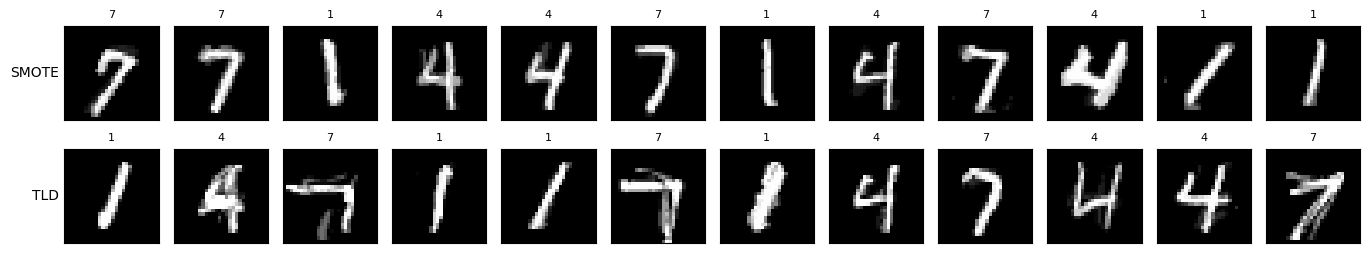

In [23]:
plot_mnist_samples(generated, n_per_generator=12, seed=None);

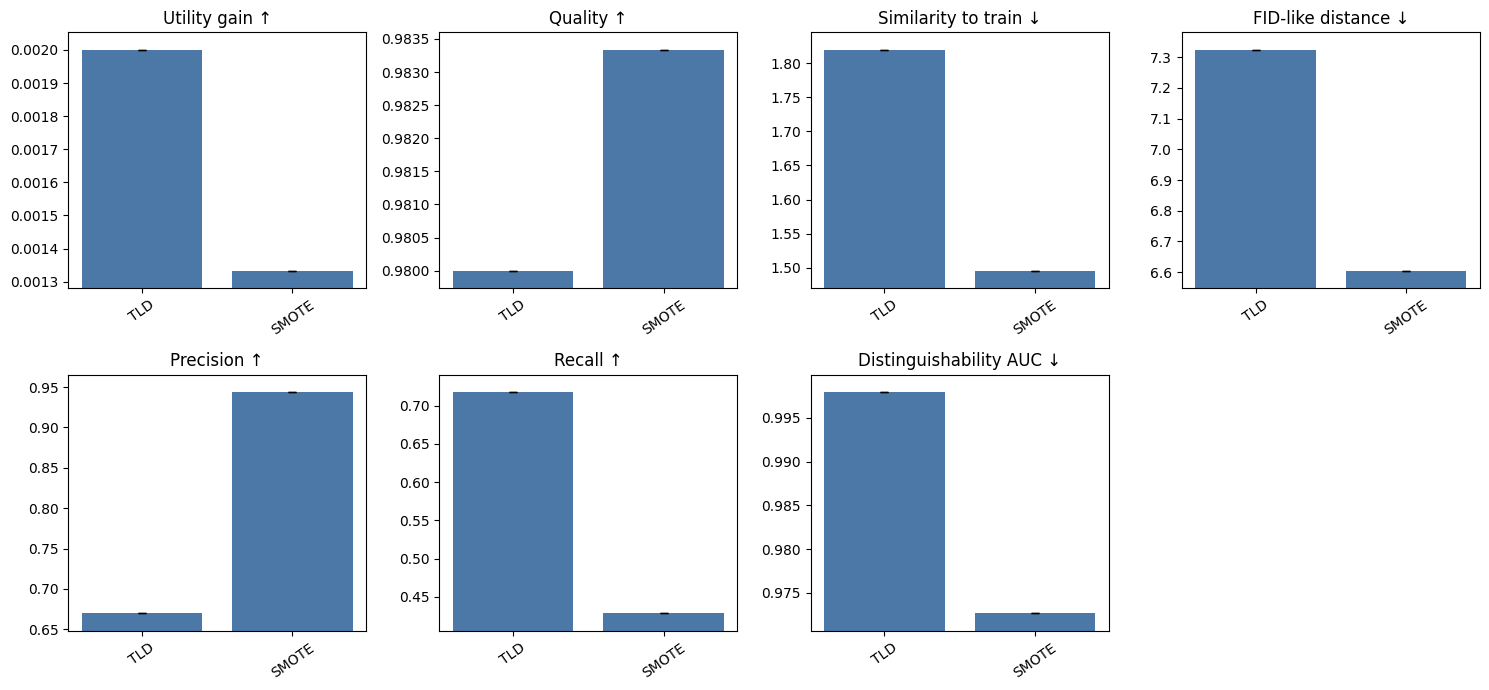

In [24]:
plot_metric_bars(result);

`test_per_class` is the held-out set for downstream accuracy and utility gain. `oracle_per_class` is a separate real sample used for diagnostics such as quality, FID-like distance, precision/recall, and real-vs-generated distinguishability.